# Patient Profile Creation

Install required packages

In [1]:
!pip install -q scikit-learn scipy

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import logging
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy import stats

In [3]:
# Configure paths
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1] / "1" / "Features"

# Feature file names
FILES_CONFIG = {
    'laboratory_tests': 'laboratory_tests_features.csv',
    'procedures': 'procedure_code_features.csv',
    'heart_diagnoses': 'heart_diagnoses_features.csv',
    'microbiology': 'microbiology_events_features.csv'
}

print(f"Feature Path: {FEATURE_PATH}")
print(f"Configuration loaded")

Feature Path: /home/gabriele/DAD/project/Tasks/1/Features
Configuration loaded


In [4]:
# Load all feature tables
dfs = {}
for key, filename in FILES_CONFIG.items():
    filepath = FEATURE_PATH / filename
    dfs[key] = pd.read_csv(filepath)
    print(f"\n{key.upper()}")
    print(f"  Shape: {dfs[key].shape}")
    print(f"  Columns: {list(dfs[key].columns)[:5]}...")


LABORATORY_TESTS
  Shape: (4751, 32)
  Columns: ['hadm_id', 'total_tests', 'n_invalid', 'tests_days_span', 'perc_invalid']...

PROCEDURES
  Shape: (3459, 5)
  Columns: ['subject_id', 'hadm_id', 'total_procedures', 'unique_procedures', 'procedures_days_span']...

HEART_DIAGNOSES
  Shape: (4864, 29)
  Columns: ['subject_id', 'hadm_id', 'age', 'gender', 'wall_motion_abnormality']...

MICROBIOLOGY
  Shape: (2756, 12)
  Columns: ['subject_id', 'hadm_id', 'infection_present', 'num_positive_cultures', 'num_unique_organisms']...


## Data Merging

In [5]:
print("\nHeart Diagnoses + Microbiology")

# Merge heart diagnoses with microbiology
heart_microbiology = pd.merge(
    dfs['heart_diagnoses'],
    dfs['microbiology'],
    on=['subject_id', 'hadm_id'],
    how='outer',
    suffixes=('_heart', '_microbio')
)

print(f" Heart + Microbiology shape: {heart_microbiology.shape}")
print(f"   Unique patients: {heart_microbiology['subject_id'].nunique()}")


Heart Diagnoses + Microbiology
 Heart + Microbiology shape: (5166, 39)
   Unique patients: 4694


In [6]:
print("\nAdd Procedures")

# merge with procedures
heart_micro_procedures = pd.merge(
    heart_microbiology,
    dfs['procedures'],
    on=['subject_id', 'hadm_id'],
    how='outer',
    suffixes=('', '_proc')
)

print(f" Heart + Microbiology + Procedures shape: {heart_micro_procedures.shape}")
print(f"Unique patients: {heart_micro_procedures['subject_id'].nunique()}")


Add Procedures
 Heart + Microbiology + Procedures shape: (5166, 42)
Unique patients: 4694


In [7]:
# Merge with laboratory tests
patient_admissions = pd.merge(
    heart_micro_procedures,
    dfs['laboratory_tests'],
    on='hadm_id',
    how='outer',
    suffixes=('', '_lab')
)

patient_admissions['hadm_id'] = patient_admissions['hadm_id'].astype('Int64')

print(f"  Final merged shape: {patient_admissions.shape}")
print(f"  Unique patients: {patient_admissions['subject_id'].nunique()}")
print(f"  Total admissions: {patient_admissions['hadm_id'].nunique()}")

  Final merged shape: (5166, 73)
  Unique patients: 4694
  Total admissions: 4761


In [8]:
patient_admissions.head()

,subject_id,hadm_id,age,gender,wall_motion_abnormality,temperature,bp_systolic,bp_diastolic,heart_rate,respiratory_rate,...,creat_n,creat_n_abnormal,creat_abnormal_ratio,glu_min,glu_max,glu_n,glu_n_abnormal,glu_abnormal_ratio,glu_var,na_cl_ratio
0,12869457,20004456,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,1.386294,1.386294,1.000000,4.836282,5.267858,1.386294,1.386294,1.00,3.635924,1.333333
1,13709807,20007905,NaN,NaN,0.0,NaN,135.0,62.0,127.0,29.0,...,2.079442,0.693147,0.142857,5.446737,5.752573,1.945910,1.945910,1.00,3.429016,1.396423
2,19997460,20007905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.079442,0.693147,0.142857,5.446737,5.752573,1.945910,1.945910,1.00,3.429016,1.396423
3,19997485,20007905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.079442,0.693147,0.142857,5.446737,5.752573,1.945910,1.945910,1.00,3.429016,1.396423
4,12002285,20013519,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,1.609438,1.609438,1.000000,4.317488,4.653960,1.609438,0.693147,0.25,2.690883,1.345070


In [9]:
patient_admissions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5166 entries, 0 to 5165
Data columns (total 73 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   subject_id                     5166 non-null   int64  
 1   hadm_id                        5166 non-null   Int64  
 2   age                            1363 non-null   float64
 3   gender                         1363 non-null   object 
 4   wall_motion_abnormality        4285 non-null   float64
 5   temperature                    2426 non-null   float64
 6   bp_systolic                    2383 non-null   float64
 7   bp_diastolic                   2383 non-null   float64
 8   heart_rate                     2255 non-null   float64
 9   respiratory_rate               2178 non-null   float64
 10  oxygen_saturation              3894 non-null   float64
 11  heart_failure_severity_score   4864 non-null   float64
 12  cad_severity_score             4864 non-null   f

## Aggregation of the features at patient level

In this phase, we aggregate the measure reported at admission level to form a patient-wise report. 

For creating the patient profile, we use aggregation rules for the creation of patient-wise features which aggregates measures taken from patient's admission  

In [10]:
# Categorize features by aggregation method
aggregation_rules = {
    # ========== IDENTIFIERS ==========
    'subject_id': 'first',  # Keep patient ID
    
    # ========== DEMOGRAPHICS (take from any admission) ==========
    'age': 'first',         # Age should be consistent across admissions
    'gender': 'first',      # Gender is constant
    
    # ========== CONTINUOUS FEATURES (worst value) ==========
    # For clinical severity: take WORST value across admissions
    'temperature': 'max',           # Fever = worse
    'bp_systolic': 'mean',          # Average BP more stable
    'bp_diastolic': 'mean',
    'heart_rate': 'max',            # Tachycardia = worse
    'respiratory_rate': 'max',      # Tachypnea = worse
    'oxygen_saturation': 'min',     # Hypoxia = worse (lower is worse)
    
    # ========== CARDIAC FUNCTION (worst) ==========
    'cardiac_index': 'min',         # Lower CI = worse
    'pcwp': 'max',                  # Higher PCWP = worse
    
    # ========== COMPOSITE SCORES (worst) ==========
    'heart_failure_severity_score': 'max',
    'cad_severity_score': 'max',
    'valvular_disease_score': 'max',
    'ecg_abnormality_score': 'max',
    'respiratory_distress_score': 'max',
    'exam_abnormality_score': 'max',
    'ct_complications_score': 'max',
    'cardiac_remodeling_score': 'max',
    'stenosis_severity_score': 'max',
    'hemodynamic_instability_score': 'max',
    
    # ========== LABORATORY TESTS (aggregate) ==========
    'total_tests': 'sum',           # Total across all admissions
    'n_invalid': 'sum',             # Total abnormal tests
    'tests_days_span': 'sum',       # Total monitoring days
    'perc_invalid': 'mean',         # Average abnormality rate
    
    # Electrolytes (worst values)
    'k_min': 'min',
    'k_max': 'max',
    'k_n': 'sum',
    'k_abnormal_ratio': 'mean',
    
    'na_min': 'min',
    'na_max': 'max',
    'na_n': 'sum',
    'na_abnormal_ratio': 'mean',
    
    'cl_min': 'min',
    'cl_max': 'max',
    'cl_n': 'sum',
    'cl_abnormal_ratio': 'mean',
    
    'creat_max': 'max',             # Worst kidney function
    'creat_n': 'sum',
    'creat_abnormal_ratio': 'mean',
    
    'glu_max': 'max',               # Worst glucose control
    'glu_n': 'sum',
    'glu_abnormal_ratio': 'mean',
    'glu_var': 'mean',              # Average variability
    
    'na_cl_ratio': 'mean',
    
    # ========== PROCEDURES (aggregate) ==========
    'total_procedures': 'sum',      # Total procedures across admissions
    'unique_procedures': 'sum',     # Sum of unique procedures
    'procedures_days_span': 'sum',
    
    # ========== MICROBIOLOGY (aggregate) ==========
    'infection_present': 'max',     # Ever had infection
    'num_positive_cultures': 'sum',
    'num_unique_organisms': 'sum',
    'days_to_first_positive': 'min',
    'antibiotic_resistant': 'max',
    'resistant_organisms_count': 'sum',
    'fungal_infection': 'max',
    'gram_positive_present': 'max',
    'gram_negative_present': 'max'
}

# Count aggregation strategies
agg_counts = pd.Series(aggregation_rules.values()).value_counts()
print("\nAggregation strategy distribution:")
for method, count in agg_counts.items():
    print(f"  • {method}: {count} features")


Aggregation strategy distribution:
  • max: 24 features
  • sum: 14 features
  • mean: 10 features
  • min: 6 features
  • first: 3 features


Now, we apply this aggregation:

In [11]:
# Filter rules to only include columns present in dataset
valid_rules = {col: method for col, method in aggregation_rules.items() 
               if col in patient_admissions.columns}

print(f"\nFeatures to aggregate: {len(valid_rules)}")
print(f"Features not in dataset: {len(aggregation_rules) - len(valid_rules)}")

# Group by patient and aggregate
patient_profiles = patient_admissions.groupby('subject_id').agg(valid_rules).reset_index(drop=True)

print(f"\n Patient-wise aggregation completed")
print(f"   Original shape (admission-level): {patient_admissions.shape}")
print(f"   Aggregated shape (patient-level): {patient_profiles.shape}")
print(f"   Features per patient: {patient_profiles.shape[1]}")


Features to aggregate: 51
Features not in dataset: 6

 Patient-wise aggregation completed
   Original shape (admission-level): (5166, 73)
   Aggregated shape (patient-level): (4694, 51)
   Features per patient: 51


In [12]:
patient_profiles.head()

,subject_id,age,gender,temperature,bp_systolic,bp_diastolic,heart_rate,respiratory_rate,oxygen_saturation,cardiac_index,...,glu_n,glu_abnormal_ratio,glu_var,na_cl_ratio,total_procedures,unique_procedures,procedures_days_span,infection_present,num_positive_cultures,num_unique_organisms
0,10000980,75.0,F,36.7,200.0,103.0,65.0,26.0,100.0,NaN,...,3.178054,0.678571,3.419946,1.326521,2.079442,2.079442,0.00000,0.0,0.0,0.0
1,10002013,NaN,None,37.4,157.0,88.0,118.0,24.0,96.0,NaN,...,1.098612,1.000000,2.848592,1.382653,1.098612,1.098612,0.00000,NaN,0.0,0.0
2,10002155,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.833213,0.687500,2.421667,1.337646,2.197225,2.197225,2.70805,0.0,0.0,0.0
3,10004457,66.0,M,NaN,NaN,NaN,NaN,NaN,98.0,NaN,...,0.693147,0.000000,NaN,1.361905,0.000000,0.000000,0.00000,NaN,0.0,0.0
4,10007058,48.0,M,36.8,123.0,71.0,63.0,21.0,99.0,NaN,...,1.791759,0.800000,2.102947,1.339114,1.098612,1.098612,0.00000,0.0,0.0,0.0


## Data Quality Assessment

### Missing values analysis

We calculate missing percentage for each feature

We divide the features into:
- "good" if they have < 20% missing values
- "moderate" if they have a missing rate between 20% and 40%
- "risky" otherwise

In [13]:
# Define thresholds
THRESHOLD_RISKY = 40      # >40% = risky
THRESHOLD_MODERATE = 20   # 20-40% = moderate
# <20% = good

# Missing data analysis
missing_stats = pd.DataFrame({
    'Feature': patient_profiles.columns,
    'Missing_Count': patient_profiles.isnull().sum(),
    'Missing_Pct': (patient_profiles.isnull().sum() / len(patient_profiles) * 100).round(2)
}).sort_values('Missing_Pct', ascending=False)

print(f"  Features with NO missing: {(missing_stats['Missing_Count'] == 0).sum()}")
print(f"  Features with <20% missing: {(missing_stats['Missing_Pct'] < THRESHOLD_MODERATE).sum()}")
print(f"  Features with >40% missing: {(missing_stats['Missing_Pct'] > THRESHOLD_RISKY).sum()}")


  Features with NO missing: 14
  Features with <20% missing: 40
  Features with >40% missing: 10


In [14]:
missing_stats['Category'] = pd.cut(
    missing_stats['Missing_Pct'],
    bins=[-0.1, THRESHOLD_MODERATE, THRESHOLD_RISKY, 100],
    labels=['GOOD', 'MODERATE', 'RISKY']
)

In [15]:
# Show top missing features
print("\nTop 15 features with missing data:")
print(missing_stats[missing_stats['Missing_Count'] > 0].head(15).to_string(index=False))


Top 15 features with missing data:
                   Feature  Missing_Count  Missing_Pct Category
             cardiac_index           4490        95.65    RISKY
                      pcwp           4475        95.33    RISKY
                       age           3430        73.07    RISKY
                    gender           3430        73.07    RISKY
          respiratory_rate           2630        56.03    RISKY
                heart_rate           2564        54.62    RISKY
               bp_systolic           2455        52.30    RISKY
              bp_diastolic           2455        52.30    RISKY
               temperature           2417        51.49    RISKY
         infection_present           2078        44.27    RISKY
         oxygen_saturation           1133        24.14 MODERATE
                   glu_var            349         7.44     GOOD
        cad_severity_score            302         6.43     GOOD
respiratory_distress_score            302         6.43     GOOD
    

### Features removal

We can delete the "risky" features which have a lot of missing values because they are not informative to us at patient level. 

In [16]:
exclude_features = ['subject_id', 'hadm_id', 'dod']

In [17]:
good_features = missing_stats[
    (missing_stats['Category'] == 'GOOD') & 
    (~missing_stats['Feature'].isin(exclude_features))
]['Feature'].tolist()

moderate_features = missing_stats[
    (missing_stats['Category'] == 'MODERATE') & 
    (~missing_stats['Feature'].isin(exclude_features))
]['Feature'].tolist()

risky_features = missing_stats[
    (missing_stats['Category'] == 'RISKY') & 
    (~missing_stats['Feature'].isin(exclude_features))
]['Feature'].tolist()

In [18]:
critical_moderate = {
    'atrial_fibrillation': 'Strong mortality predictor',
    'lbbb': 'Heart failure marker',
    'st_elevation': 'Acute MI indicator',
    'st_depression': 'Ischemia marker',
    'oxygen_saturation': 'Vital sign',
    'q_waves': 'Old MI marker',
    'temperature': 'Vital sign'
}

moderate_to_keep = [f for f in moderate_features if f in critical_moderate]
moderate_to_remove = [f for f in moderate_features if f not in critical_moderate]

In [19]:
features_to_keep = good_features + moderate_to_keep
features_to_remove = risky_features + moderate_to_remove

In [20]:
df_filtered = patient_profiles[['subject_id'] + features_to_keep].copy()


### Handling missing values on moderate and good features

#### Identify feature types (binary vs continuous)

In [21]:
binary_features = []
continuous_features = []

for col in features_to_keep:
    if col in df_filtered.columns:
        # Check unique non-null values
        unique_vals = df_filtered[col].dropna().unique()
        
        # Binary: only 0 and 1 (or True/False)
        if len(unique_vals) <= 2:
            if all(v in [0, 1, 0.0, 1.0, True, False] for v in unique_vals):
                binary_features.append(col)
            else:
                continuous_features.append(col)
        else:
            continuous_features.append(col)

In [22]:
print("\n   Binary features (sample):")
for feat in binary_features[:10]:
    n_missing = df_filtered[feat].isnull().sum()
    print(f"      • {feat:<40} {n_missing} missing")
if len(binary_features) > 10:
    print(f"      ... and {len(binary_features)-10} more")


   Binary features (sample):


In [23]:
print("\n   Continuous features (sample):")
for feat in continuous_features[:10]:
    n_missing = df_filtered[feat].isnull().sum()
    print(f"      • {feat:<40} {n_missing} missing")
if len(continuous_features) > 10:
    print(f"      ... and {len(continuous_features)-10} more")


   Continuous features (sample):
      • glu_var                                  349 missing
      • cad_severity_score                       302 missing
      • respiratory_distress_score               302 missing
      • ecg_abnormality_score                    302 missing
      • ct_complications_score                   302 missing
      • exam_abnormality_score                   302 missing
      • valvular_disease_score                   302 missing
      • heart_failure_severity_score             302 missing
      • stenosis_severity_score                  302 missing
      • cardiac_remodeling_score                 302 missing
      ... and 30 more


#### add missingness indicators for moderate features

In [24]:
missingness_indicators = []

for feature in moderate_to_keep:
    if feature in df_filtered.columns:
        # Create indicator: 1 = measured, 0 = not measured
        indicator_name = f'{feature}_measured'
        df_filtered[indicator_name] = (~df_filtered[feature].isnull()).astype(int)
        missingness_indicators.append(indicator_name)
        
        measured = df_filtered[indicator_name].sum()
        not_measured = len(df_filtered) - measured
        
        print(f"  ✓ {indicator_name}")
        print(f"     Measured: {measured} ({measured/len(df_filtered)*100:.1f}%)")
        print(f"     Not measured: {not_measured} ({not_measured/len(df_filtered)*100:.1f}%)")

  ✓ oxygen_saturation_measured
     Measured: 3561 (75.9%)
     Not measured: 1133 (24.1%)


Now we can impute missing values.

Let's start from binary features...

In [25]:
binary_imputation_log = []

for col in binary_features:
    if col in df_filtered.columns:
        n_missing = df_filtered[col].isnull().sum()
        
        if n_missing > 0:
            # Calculate mode
            mode_val = df_filtered[col].mode()[0] if not df_filtered[col].mode().empty else 0
            
            # Impute
            df_filtered[col].fillna(mode_val, inplace=True)
            
            binary_imputation_log.append({
                'Feature': col,
                'Missing_Count': n_missing,
                'Imputed_Value': mode_val
            })
            
            print(f"{col:<40} {n_missing:>4} missing → {int(mode_val)}")

print(f"\nImputed {len(binary_imputation_log)} binary features")


Imputed 0 binary features


And continue with continuous features: we use KNN imputer if there is possibility, otherwise we use median fallback

In [26]:
from sklearn.impute import KNNImputer


if len(continuous_features) > 0:
    continuous_data = df_filtered[continuous_features].copy()
    for col in continuous_data.columns:
        if continuous_data[col].dtype == 'object':
            try:
                continuous_data[col] = pd.to_numeric(continuous_data[col])
            except:
                continuous_features.remove(col)
    
    missing_before = continuous_data.isnull().sum()
    features_with_missing = missing_before[missing_before > 0]
    
    print(f"Features requiring imputation: {len(features_with_missing)}\n")
    
    # KNN Imputation
    knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
    
    try:
        continuous_imputed = knn_imputer.fit_transform(continuous_data)
        
        # Update dataframe
        df_filtered[continuous_features] = continuous_imputed
        
        # Log imputation
        for feat in features_with_missing.index:
            print(f"  ✓ {feat:<40} {missing_before[feat]:>4} missing → KNN imputed")
        
        print(f"\nKNN imputation completed for {len(features_with_missing)} continuous features")
        print(f"   Method: k=5 nearest neighbors with distance weighting")
        
    except Exception as e:
        print(f"\nKNN imputation failed: {str(e)}")
        print("   Falling back to median imputation...")
        
        # Fallback: median imputation
        for col in continuous_features:
            if df_filtered[col].isnull().any():
                median_val = df_filtered[col].median()
                df_filtered[col].fillna(median_val, inplace=True)
                print(f"  ✓ {col:<40} imputed with median: {median_val:.2f}")
else:
    print("No continuous features requiring imputation")

Features requiring imputation: 27

  ✓ glu_var                                   349 missing → KNN imputed
  ✓ cad_severity_score                        302 missing → KNN imputed
  ✓ respiratory_distress_score                302 missing → KNN imputed
  ✓ ecg_abnormality_score                     302 missing → KNN imputed
  ✓ ct_complications_score                    302 missing → KNN imputed
  ✓ exam_abnormality_score                    302 missing → KNN imputed
  ✓ valvular_disease_score                    302 missing → KNN imputed
  ✓ heart_failure_severity_score              302 missing → KNN imputed
  ✓ stenosis_severity_score                   302 missing → KNN imputed
  ✓ cardiac_remodeling_score                  302 missing → KNN imputed
  ✓ hemodynamic_instability_score             302 missing → KNN imputed
  ✓ glu_max                                    30 missing → KNN imputed
  ✓ glu_abnormal_ratio                         30 missing → KNN imputed
  ✓ na_abnormal_ratio        

In [27]:
patient_profiles = df_filtered.copy()

## Dimensionality Reduction

In [28]:
numeric_cols = patient_profiles.select_dtypes(include='number').columns
features_cols = [col for col in numeric_cols if col not in ['subject_id']]

In [29]:
# Create working dataframe
X = patient_profiles[features_cols].copy()

In [30]:
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.01)
sel.fit(X)
low_variance_features = X.columns[~sel.get_support()].tolist()
print(f"\nLow variance features removed ({len(low_variance_features)}): {low_variance_features}")

X = X.loc[:, sel.get_support()]
print(f"After variance filter: {X.shape[1]} features")



Low variance features removed (3): ['na_min', 'na_cl_ratio', 'k_abnormal_ratio']
After variance filter: 38 features


In [31]:
import numpy as np
corr_matrix = X.corr()
print(f"Correlation matrix: {corr_matrix.shape}")

Correlation matrix: (38, 38)


In [32]:
# Find High correlation feature pairs
def find_high_correlations(corr_matrix, threshold=0.8):
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr_pairs.append({
                    'feature_1': corr_matrix.columns[i],
                    'feature_2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr_pairs).sort_values('correlation', key=abs, ascending=False)

In [33]:
high_corr = find_high_correlations(corr_matrix, threshold=0.8)
print(high_corr)

                feature_1                feature_2  correlation
8                    na_n                     cl_n     0.999319
30       total_procedures        unique_procedures     0.998179
3                    na_n                      k_n     0.995125
19                    k_n                     cl_n     0.994640
7                    na_n                  creat_n     0.994334
18                    k_n                  creat_n     0.994316
29                creat_n                     cl_n     0.993983
27                  glu_n                  creat_n     0.984130
28                  glu_n                     cl_n     0.982909
6                    na_n                    glu_n     0.981568
17                    k_n                    glu_n     0.979494
10            total_tests                n_invalid     0.957859
25        tests_days_span                  creat_n     0.947149
15                    k_n                n_invalid     0.944820
22              n_invalid               

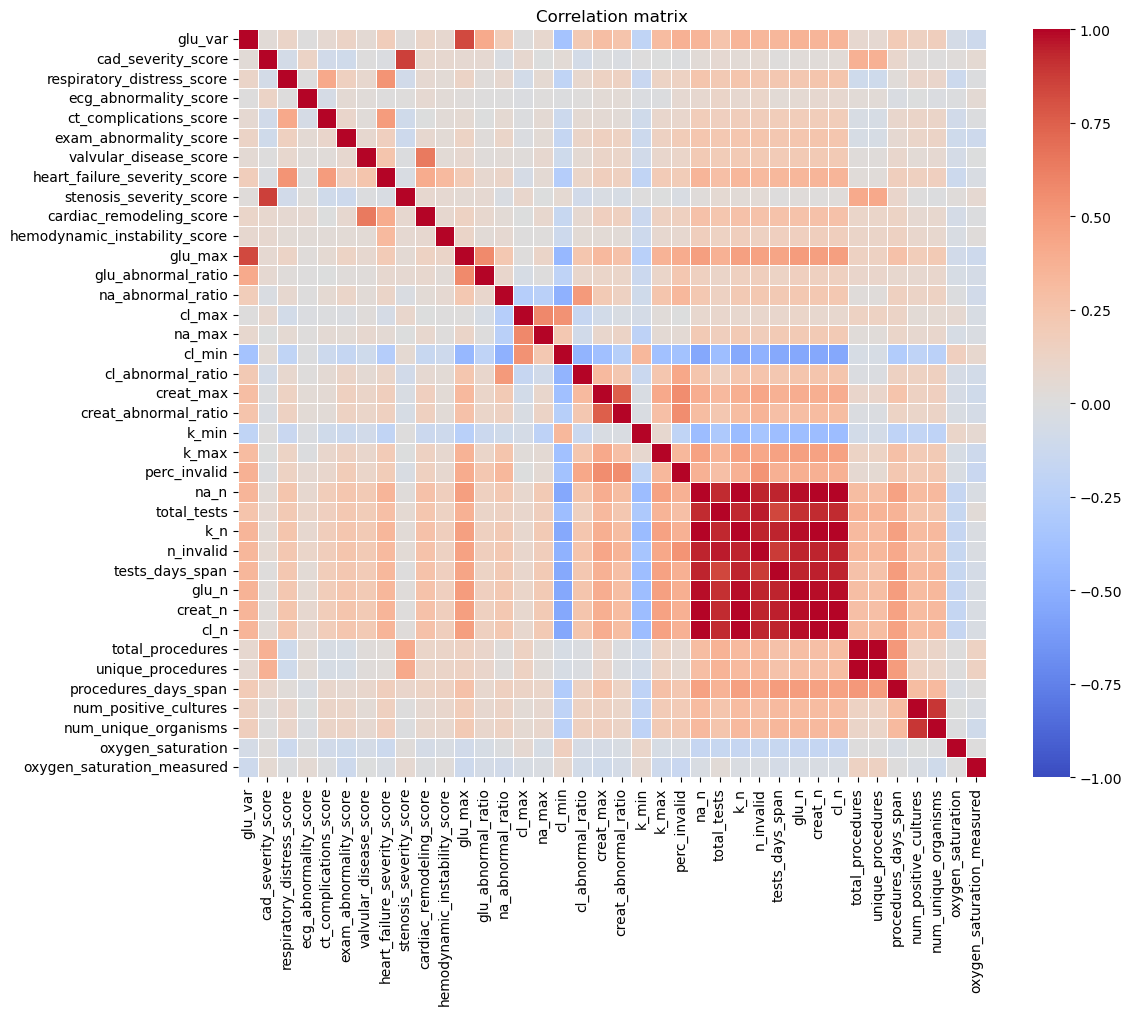

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap base
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=False,  
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()


As we can see, there are lot of redundant features, so we have to choose which ones to keep and which ones to discard.

In [35]:
features_to_remove = set()
for _, row in high_corr.iterrows():
    features_to_remove.add(row['feature_2'])

print(f"\nRedundant features ({len(features_to_remove)}):")
for feature in sorted(features_to_remove):
    print(f"  - {feature}")


Redundant features (11):
  - cl_n
  - creat_n
  - glu_max
  - glu_n
  - k_n
  - n_invalid
  - num_unique_organisms
  - stenosis_severity_score
  - tests_days_span
  - total_tests
  - unique_procedures


In [36]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

print(f"Starting features: {len(features_cols)}")
print(f"Features: {features_cols}")

#Remove highly correlated features (threshold 0.80)
corr = X.corr()
high_corr = set()
corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.80:
            corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))
            high_corr.add(corr.columns[j])  # Remove the second feature

print(f"\nHighly correlated pairs found (|r| > 0.80): {len(corr_pairs)}")
if len(corr_pairs) > 0:
    print("\nSome examples of high correlations:")
    for feat1, feat2, corr_val in sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"  {feat1} <-> {feat2}: {corr_val:.3f}")

print(f"\nFeatures to remove due to high correlation ({len(high_corr)}): {sorted(high_corr)}")

X = X.drop(columns=list(high_corr), errors='ignore')
print(f"\nAfter correlation filter: {X.shape[1]} features")

# Step 4: Create final dataset
final_features = ['subject_id'] + X.columns.tolist()
patient_profiles_clean = patient_profiles[final_features].copy()

Starting features: 41
Features: ['glu_var', 'cad_severity_score', 'respiratory_distress_score', 'ecg_abnormality_score', 'ct_complications_score', 'exam_abnormality_score', 'valvular_disease_score', 'heart_failure_severity_score', 'stenosis_severity_score', 'cardiac_remodeling_score', 'hemodynamic_instability_score', 'glu_max', 'glu_abnormal_ratio', 'na_abnormal_ratio', 'na_min', 'cl_max', 'na_max', 'cl_min', 'na_cl_ratio', 'cl_abnormal_ratio', 'creat_max', 'creat_abnormal_ratio', 'k_abnormal_ratio', 'k_min', 'k_max', 'perc_invalid', 'na_n', 'total_tests', 'k_n', 'n_invalid', 'tests_days_span', 'glu_n', 'creat_n', 'cl_n', 'total_procedures', 'unique_procedures', 'procedures_days_span', 'num_positive_cultures', 'num_unique_organisms', 'oxygen_saturation', 'oxygen_saturation_measured']

Highly correlated pairs found (|r| > 0.80): 32

Some examples of high correlations:
  na_n <-> cl_n: 0.999
  total_procedures <-> unique_procedures: 0.998
  na_n <-> k_n: 0.995
  k_n <-> cl_n: 0.995
  na_

In [37]:
missing_counts = patient_profiles_clean.isna().sum()
missing_pct = (missing_counts / len(patient_profiles_clean) * 100).round(2)
missing_df = pd.DataFrame({
    'Feature': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Pct': missing_pct.values
}).sort_values('Missing_Pct', ascending=False)

In [38]:
missing_df[missing_df['Missing_Pct'] > 0].shape

(0, 3)

In [39]:
missing_df[missing_df['Missing_Pct'] > 0].head(15)

,Feature,Missing_Count,Missing_Pct


## Final dataset statistics

In [40]:
print("\n=== FINAL DATASET STATISTICS ===")

print(f"\n Patient Coverage:")
print(f"   Total unique patients: {patient_profiles['subject_id'].nunique()}")
print(f"   Complete cases (no missing): {patient_profiles.dropna().shape[0]}")

# Numeric summary
numeric_final = patient_profiles_clean.select_dtypes(include=[np.number])

print(f"\nNumeric Features Summary:")
summary_stats = numeric_final.describe().round(3)
print(summary_stats.iloc[[1, 2, 3, 4, 5, 7]].T.head(15))


=== FINAL DATASET STATISTICS ===

 Patient Coverage:
   Total unique patients: 4694
   Complete cases (no missing): 4694

Numeric Features Summary:
                                       mean          std         min  \
subject_id                     1.544012e+07  3089376.428  10000980.0   
glu_var                        2.957000e+00        0.885         0.0   
cad_severity_score             5.350000e-01        0.983         0.0   
respiratory_distress_score     1.229000e+00        1.206         0.0   
ecg_abnormality_score          9.820000e-01        1.460         0.0   
ct_complications_score         6.150000e-01        1.415         0.0   
exam_abnormality_score         2.185000e+00        1.024         0.0   
valvular_disease_score         1.856000e+00        1.236         0.0   
heart_failure_severity_score   1.446000e+00        1.639         0.0   
cardiac_remodeling_score       2.173000e+00        1.789         0.0   
hemodynamic_instability_score  1.340000e-01        0.535   

In [41]:
columns_final = numeric_final.columns
continuous_cols_only = [c for c in columns_final if patient_profiles_clean[c].nunique() > 2]
skewness = patient_profiles_clean[continuous_cols_only].skew().sort_values(ascending=False)

# 3. Mostra chi supera la soglia di allarme (solitamente 1 o 0.75)
skewed_features = skewness[abs(skewness) > 1]
print("Feature fortemente asimmetriche (da trasformare):")
print(skewed_features)

Feature fortemente asimmetriche (da trasformare):
hemodynamic_instability_score    5.162618
num_positive_cultures            3.264309
ct_complications_score           2.669305
na_abnormal_ratio                2.527980
procedures_days_span             2.509922
na_n                             1.983774
cad_severity_score               1.927830
creat_max                        1.824986
ecg_abnormality_score            1.658883
heart_failure_severity_score     1.564327
cl_abnormal_ratio                1.512205
k_max                            1.057413
oxygen_saturation               -1.314474
dtype: float64


In [42]:
# Save the processed dataset
output_path = 'patient_profiles.csv'
patient_profiles_clean.to_csv(Path().resolve().parent / 'Features' / output_path, index=False)